In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv('/kaggle/input/datasets/d4rklucif3r/social-network-ads/Social_Network_Ads.csv')

In [7]:
df.sample(10)

,Age,EstimatedSalary,Purchased
178,24,23000,0
175,23,28000,0
329,47,107000,1
278,52,38000,1
145,24,89000,0
152,31,76000,0
98,35,73000,0
318,45,32000,1
251,37,52000,0
42,35,108000,0


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
train_X,test_X,train_y,test_y=train_test_split(df.drop('Purchased',axis=1),
                                              df['Purchased'],
                                              test_size=0.3,
                                              random_state=0)

In [10]:
train_X.shape,test_X.shape

((280, 2), (120, 2))

In [11]:
train_X.head()

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000


In [12]:
test_X.head()

,Age,EstimatedSalary
132,30,87000
309,38,50000
341,35,75000
196,30,79000
246,35,50000


In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler=StandardScaler()

In [15]:
scaler.fit(train_X)

StandardScaler()

In [16]:
train_X_scaled=scaler.transform(train_X)
test_X_scaled=scaler.transform(test_X)

In [17]:
train_X_scaled=pd.DataFrame(train_X_scaled,columns=train_X.columns)
test_X_scaled=pd.DataFrame(test_X_scaled,columns=test_X.columns)


In [18]:
train_X_scaled.head()

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047


In [19]:
test_X_scaled.head()

,Age,EstimatedSalary
0,-0.771013,0.497201
1,0.013305,-0.572804
2,-0.280814,0.150172
3,-0.771013,0.265849
4,-0.280814,-0.572804


In [20]:
np.round(train_X_scaled.describe(),2)

,Age,EstimatedSalary
count,280.00,280.00
mean,0.00,0.00
std,1.00,1.00
min,-1.95,-1.58
25%,-0.77,-0.78
50%,-0.08,0.02
75%,0.80,0.53
max,2.17,2.32


In [21]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [22]:
np.round(test_X_scaled.describe(),2)

,Age,EstimatedSalary
count,120.00,120.00
mean,-0.07,-0.01
std,1.09,0.95
min,-1.95,-1.58
25%,-0.97,-0.66
50%,-0.18,-0.15
75%,0.72,0.50
max,2.17,2.32


In [23]:
test_X_scaled.head()

,Age,EstimatedSalary
0,-0.771013,0.497201
1,0.013305,-0.572804
2,-0.280814,0.150172
3,-0.771013,0.265849
4,-0.280814,-0.572804


Text(0.5, 1.0, 'After Scalling')

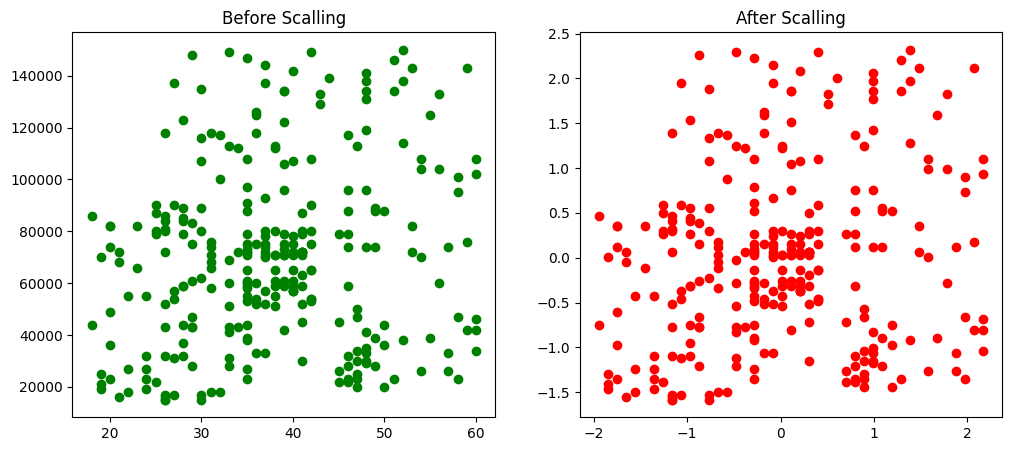

In [64]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(train_X['Age'],train_X['EstimatedSalary'],color='green')
ax1.set_title("Before Scalling")
ax2.scatter(train_X_scaled['Age'],train_X_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scalling")

<Axes: title={'center': 'After Scattering'}, xlabel='Age', ylabel='Density'>

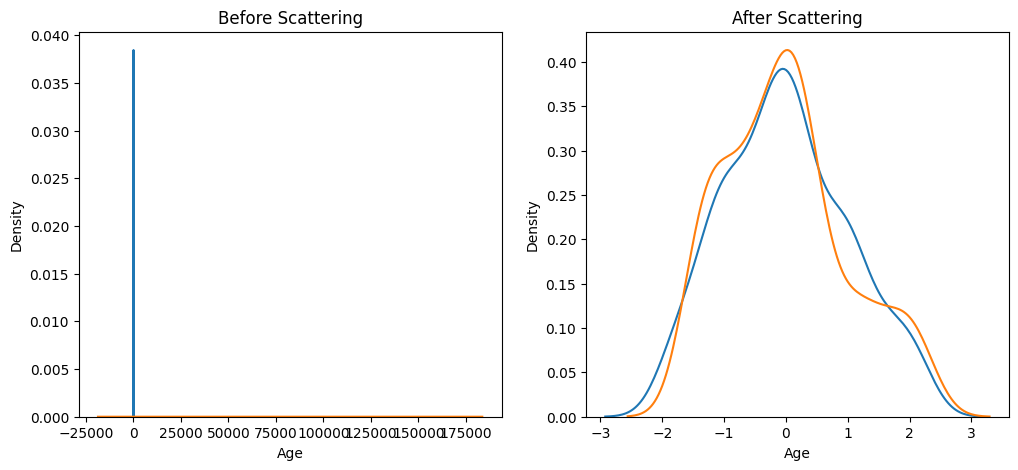

In [25]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title("Before Scalling")
sns.kdeplot(train_X['Age'],ax=ax1)
sns.kdeplot(train_X['EstimatedSalary'],ax=ax1)

ax2.set_title("After Scalling")
sns.kdeplot(train_X_scaled['Age'],ax=ax2)
sns.kdeplot(train_X_scaled['EstimatedSalary'],ax=ax2)

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [46]:
lr.fit(train_X,train_y)
lr_scaled.fit(train_X_scaled,train_y)

LogisticRegression()

In [47]:
y_pred=lr.predict(test_X)
y_pred_scaled=lr_scaled.predict(test_X_scaled)

In [48]:
from sklearn.metrics import accuracy_score

In [55]:
print("Actual:",accuracy_score(test_y,y_pred))
print("Scaled:",accuracy_score(test_y,y_pred_scaled))

Actual: 0.875
Scaled: 0.8666666666666667


In [50]:
from sklearn.tree import DecisionTreeClassifier

In [58]:
dt=DecisionTreeClassifier(random_state=42)
dt_scaled=DecisionTreeClassifier(random_state=42)

In [59]:
dt.fit(train_X,train_y)
dt_scaled.fit(train_X_scaled,train_y)

DecisionTreeClassifier(random_state=42)

In [60]:
y_pred_dt=dt.predict(test_X)
y_pred_scaled_dt=dt_scaled.predict(test_X_scaled)

In [61]:
print("Actual:",accuracy_score(test_y,y_pred_dt))
print("Scaled:",accuracy_score(test_y,y_pred_scaled_dt))

Actual: 0.875
Scaled: 0.8666666666666667
